# Import

### libraries

In [1]:
import sys
import os
import warnings
import random
import datetime
import itertools

import pandas as pd
import numpy as np
# viz
import matplotlib.pyplot as plt
# statistics
from scipy.stats import boxcox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
sys.path.append("../../")


from ML.metric.regression import root_mean_squared_log_error

### env & settings

In [3]:
DATA_DIR = "/workspace/Storage/kaggle/Data/insurance"
PATH_TRAIN = os.path.join(DATA_DIR, "raw", "train.csv")
PATH_TEST = os.path.join(DATA_DIR, "raw", "test.csv")

In [4]:
# 경고 출력 끄기
warnings.filterwarnings('ignore')

# 출력할 컬럼 수를 충분히 늘리기
pd.set_option('display.max_columns', None)

In [5]:
seed = 42
random.seed(seed)


### Data

In [6]:
train = pd.read_csv(PATH_TRAIN)
test = pd.read_csv(PATH_TEST)
EDA_result = pd.read_csv("EDA_result.csv")

In [7]:
data_type = EDA_result[EDA_result['transform'] != 'drop'][['name','type']].set_index('name').to_dict()['type']
intervals = EDA_result[EDA_result['type'] == 'interval']['name'].to_list()[1:]
ratios = EDA_result[EDA_result['type'] == 'ratio']['name'].to_list()
ordinals = EDA_result[EDA_result['type'] == 'ordinal']['name'].to_list()
nominals = EDA_result[EDA_result['type'] == 'nominal']['name'].to_list()
categorical = nominals + ordinals
numeric = ordinals + intervals + ratios
target = "Premium Amount"
len(intervals), len(ratios), len(ordinals), len(nominals), 

(2, 8, 4, 6)

In [8]:
# 변경
def preprocess_id(df):
    df = df.drop('id', axis=1)
    return df

def preprocess_Policy_Start_Date_1(df):
    df['Policy Start Date'] = pd.to_datetime(df['Policy Start Date'])
    return df

def preprocess_Policy_Start_Date_2(df):
    ref = "2024-08-16"
    ref = datetime.datetime.strptime(ref, "%Y-%m-%d")
    df["Policy Start Date"] = df["Policy Start Date"].map(lambda x: (ref-x).total_seconds())
    return df

def preprocess_Policy_Start_Date_3(df):
    df = df.select_dtypes(include=['number','datetime'])
    df = df.select_dtypes(include=['number','datetime'])
    df = df.set_index("Policy Start Date")
    df = df.resample('D').mean()
    return df

def preprocess_Premium_Amount_1(df):
    # box-cox?
    df["Premium Amount"] = boxcox(df["Premium Amount"])[0]
    return df

def scaling_standardization(s):
    mean = s.mean()
    std = s.std()
    return s.map(lambda x: (x-mean)/std)

def scaling_minmax(s):
    min_ = s.min()
    max_ = s.max()
    return s.map(lambda x: (x-min_)/max_)

def preprocess_scaling(df):
    booleans = list(filter(lambda x: len(x)==2, df.columns))
    remains = list(filter(lambda x: len(x)!=2, df.columns))
    df[booleans] = df[booleans].apply(scaling_minmax)
    df[remains] = df[remains].apply(scaling_standardization)
    return df

# 결측처리
def process_mv_baseline(df, EDA_result):
    EDA_result = EDA_result.set_index('name').to_dict()
    for col in df.columns:
        if EDA_result["transform"][col] == "drop":
            df.drop(col, axis=1, inplace=True)
        # elif EDA_result["mv_process"][col] == "special":
        #     df.drop(col, axis=1, inplace=True)
    df = df.dropna()
    return df

def process_mv_analysis(df, EDA_result):
    EDA_result = EDA_result.set_index('name').to_dict()
    for col in df.columns:
        if EDA_result["transform"][col] == "drop":
            df.drop(col, axis=1, inplace=True)
    return df

def process_mv_advanced(df):
    return df.dropna()

# 인코딩
def preprocess_ordinals_1(df,d):
    cols = list(d.keys())
    df[cols] = df[cols].apply(lambda col: col.map(lambda x: d[col.name][x] if not pd.isna(x) else x))
    return df

def preprocess_nominals_1(df, EDA_result):
    nominals = EDA_result[EDA_result['type']=="nominal"]['name'].to_list()
    nominals = [x for x in nominals if x in df.columns]
    df = pd.get_dummies(df, columns = nominals)
    return df


def preprocess_nominals_2(df, EDA_result):
    categoricals = EDA_result[EDA_result['type'].isin(["nominal", "ordinal"])]['name'].to_list()
    categoricals = [x for x in categoricals if x in df.columns]
    return pd.concat([df, pd.get_dummies(df[categoricals].astype(str))], axis=1)

ordinal_dict = {
    "Education Level" : {
        "High School": 1,
        "Bachelor's" : 2,
        "Master's" : 3,
        "PhD" : 4,
    },
    "Policy Type": {
        "Basic":1,
        "Comprehensive":2,
        "Premium":3
    },
    "Customer Feedback":{
        "Poor":1,
        "Average":2,
        "Good":3
    },
    "Exercise Frequency":{
        'Rarely':1,
        'Monthly':2,
        'Weekly':3,
        'Daily':4
    }
}

def pipeline_0(df, d, EDA_result):
    df_ = df.copy()
    p1 = preprocess_id(df_)
    p2 = preprocess_Policy_Start_Date_1(p1)
    p3 = preprocess_Policy_Start_Date_2(p2)
    p4 = preprocess_ordinals_1(p3,d)
    p5 = process_mv_baseline(p4, EDA_result)
    p6 = preprocess_nominals_1(p5, EDA_result)
    return p6

def pipeline_1(df, d):
    df_ = df.copy()
    p1 = preprocess_id(df_)
    p2 = preprocess_Policy_Start_Date_1(p1)
    p3 = preprocess_Policy_Start_Date_2(p2)
    p4 = preprocess_ordinals_1(p3,d)
    return p4

def pipeline_2(df, d, EDA_result):
    df_ = df.copy()
    p1 = preprocess_id(df_)
    p2 = preprocess_Policy_Start_Date_1(p1)
    p3 = preprocess_Policy_Start_Date_2(p2)
    p4 = preprocess_ordinals_1(p3,d)
    p5 = preprocess_nominals_1(p4, EDA_result)
    return p5



def pipeline_3(df, d, EDA_result):
    df_ = df.copy()
    p1 = preprocess_id(df_)
    p2 = preprocess_Policy_Start_Date_1(p1)
    p3 = preprocess_Policy_Start_Date_2(p2)
    p4 = preprocess_ordinals_1(p3,d)
    p5 = preprocess_nominals_2(p4, EDA_result)
    return p5

def pipeline_4(df, d, EDA_result):
    df_ = df.copy()
    p1 = preprocess_id(df_)
    p2 = preprocess_Policy_Start_Date_1(p1)
    p3 = preprocess_Policy_Start_Date_2(p2)
    p4 = preprocess_ordinals_1(p3,d)
    p5 = preprocess_nominals_1(p4, EDA_result)
    p6 = process_mv_advanced(p5)
    p7 = preprocess_scaling(p6)
    return p7

def pipeline_5(df, d):
    df_ = df.copy()
    p1 = preprocess_id(df_)
    p2 = preprocess_Policy_Start_Date_1(p1)
    p3 = preprocess_ordinals_1(p2,d)
    p4 = preprocess_Policy_Start_Date_3(p3)
    return p4

In [9]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder

def process_impute_mice(df, max_iter=10, categoricals = []):
    # mice는 categorical 변수를 읽지 못함. 하지만 ordinal 인코딩 하더라도 mice 알고리즘은 순서없이 계산하므로 ordinal 인코딩 후 계산하고 역변환
    if categoricals:
        # 1. Nominal 변수 Label Encoding
        les = {}
        for cat in categoricals:
            le = LabelEncoder()
            df[cat] = le.fit_transform(df[cat].fillna("nan"))  # NaN 포함 처리
            classes = dict(((str(y),x) for x,y in enumerate(le.classes_)))
            if classes.get("nan",""):
                nan_encoded = classes["nan"]
                df[cat] = df[cat].replace(nan_encoded, np.nan)
            les[cat] = le

    # MICE를 사용한 결측값 대체
    imputer = IterativeImputer(max_iter=max_iter, random_state=0)
    imputed_data = imputer.fit_transform(df)
    imputed_df = pd.DataFrame(imputed_data, columns=df.columns)

    # 역변환
    if categoricals:
        for col in categoricals:
            imputed_df[col] = imputed_df[col].round().astype(int)  # 범주형 값 정수화
            imputed_df[col] = les[col].inverse_transform(imputed_df[col])

    return imputed_df

In [10]:
def pipeline_7(df, d, EDA_result, MARS):
    df_ = df.copy()
    p1 = preprocess_id(df_)
    p2 = preprocess_Policy_Start_Date_1(p1)
    p3 = preprocess_Policy_Start_Date_2(p2)
    p4 = preprocess_ordinals_1(p3,d)
    p5 = process_impute_mice(p4, 10, EDA_result[EDA_result["type"]=='nominal']['name'].tolist())
    p4[MARS] = p5[MARS]
    p4 = p4.dropna()
    p6 = preprocess_nominals_1(p4, EDA_result)
    p7 = preprocess_scaling(p6)
    return p7

In [11]:
# 차원축소, 군집은 encoding과 missing value 처리가 필요. 군집에 최대한 정보를 반영하기 위해 MAR과 결측비율이 큰 것은 mice로 대체, 나머지 드랍. ordinal/원핫인코딩
MARS = EDA_result[EDA_result["mv_process"] == "special"]['name'].tolist() + ["Annual Income"]
train_p8 = pipeline_7(train, ordinal_dict, EDA_result, MARS)

# 0. Objective

성능 향상을 위한 데이터분석
1. 차원 축소
2. 군집 분석
3. 시계열 분석
4. 분석 함수화 및 변수 별 다양한 전처리 & 분석 재적용

따라서 산출물은
1. 차원 축소 함수
2. 가장 맞는 군집 알고리즘
3. 시계열 분석 결과
4. 실험 계획


# 1. Analysis

## 1.1 Dimensionality reduction

In [12]:
from umap import UMAP

In [13]:
X_dr = train_p8.drop(target, axis=1)
y_dr = train_p8[target]

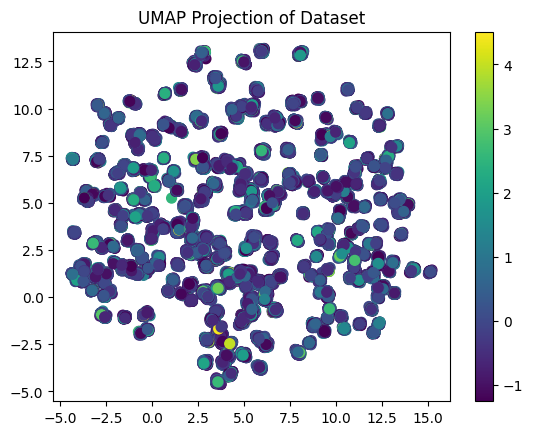

In [14]:


# UMAP 모델 생성 및 차원 축소
umap_model = UMAP(n_neighbors=15, min_dist=0.1, n_components=5, random_state=42)
X_embedded = umap_model.fit_transform(X_dr)

# 결과 시각화
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_dr, cmap='viridis', s=50)
plt.colorbar()
plt.title('UMAP Projection of Dataset')
plt.show()

## 1.2 Clustering

In [15]:
import numpy as np
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cdist

def dunn_index(data, labels):
    """
    Calculate the Dunn Index for clustering results with optimized memory usage.
    
    Parameters:
    - data: ndarray, shape (n_samples, n_features)
        The dataset.
    - labels: ndarray, shape (n_samples,)
        The cluster labels for each point in the dataset.
    
    Returns:
    - dunn_index: float
        The Dunn Index score.
    """
    unique_labels = np.unique(labels)
    inter_cluster_distances = []
    intra_cluster_distances = []
    
    # Calculate inter-cluster distances
    for i in range(len(unique_labels)):
        for j in range(i + 1, len(unique_labels)):
            cluster_i = data[labels == unique_labels[i]]
            cluster_j = data[labels == unique_labels[j]]
            
            # Use cdist for memory efficiency
            distances = cdist(cluster_i, cluster_j, metric='euclidean')
            inter_cluster_distances.append(np.min(distances))
    
    # Calculate intra-cluster distances
    for label in unique_labels:
        cluster_data = data[labels == label]
        if len(cluster_data) > 1:
            # Efficiently calculate maximum distance within the cluster
            distances = cdist(cluster_data, cluster_data, metric='euclidean')
            intra_cluster_distances.append(np.max(distances))
    
    # Dunn Index calculation
    min_inter = np.min(inter_cluster_distances)
    max_intra = np.max(intra_cluster_distances)
    
    return min_inter / max_intra

In [ ]:
safety bar

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}

# optimal k, n
for n in [6,9,12]:
    umap_model = UMAP(n_neighbors=15, min_dist=0.1, n_components=n, random_state=42)
    X_embedded = umap_model.fit_transform(X_dr)
    for k in range(2, 7):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_embedded)
        score = silhouette_score(X_embedded, labels)
        # score2 = dunn_index(X_cluster, labels)
        if not silhouette_scores.get("kmean",""):
            silhouette_scores["kmean"] = [(k, n, score)]
        else:
            silhouette_scores["kmean"].append((k, n, score))
        print(k, n, score)

2 6 0.15069902
3 6 0.18436716
4 6 0.18949777
5 6 0.20020136
6 6 0.18519212
2 9 0.11736288
3 9 0.19163147
4 9 0.2126338
5 9 0.2282743
6 9 0.20454127
2 12 0.13033143
3 12 0.1572496
4 12 0.20877624
5 12 0.15769342
6 12 0.16945909


result

- 2 6 0.15069902
- 3 6 0.18436716
- 4 6 0.18949777
- 5 6 0.20020136
- 6 6 0.18519212
- 2 9 0.11736288
- 3 9 0.19163147
- 4 9 0.2126338
- 5 9 0.2282743
- 6 9 0.20454127
- 2 12 0.13033143
- 3 12 0.1572496
- 4 12 0.20877624
- 5 12 0.15769342
- 6 12 0.16945909

n=9, k=5

오래 걸리는 계산에서 입력값 검증 함수(임시)를 만들거나 로깅을 제대로 하고, 반복문을 실행하기 전 1회 시도하고 중간 과정 검토하자.

이를 위해 함수화를 하고 진행하는 것이 나을 것 같다.

In [16]:
umap_model = UMAP(n_neighbors=15, min_dist=0.1, n_components=9, random_state=42)
X_embedded = umap_model.fit_transform(X_dr)

In [19]:
# from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# # 계층적 군집 분석 수행
# linkage_matrix = linkage(X_embedded, method='ward')

# # 덴드로그램 시각화
# plt.figure(figsize=(10, 7))
# dendrogram(linkage_matrix)
# plt.show()

In [ ]:
# threshold = 7  # 덴드로그램에서 거리 임계값 설정
# labels = fcluster(linkage_matrix, t=threshold, criterion='distance')
# silhouette_scores["hierarchy"] = [(threshold, silhouette_score(X_cluster, labels))]

계층적 군집은 메모리 이슈

In [18]:
import gc
gc.collect()

0

In [19]:
from sklearn.cluster import DBSCAN
# DBSCAN 실행
eps = 0.5
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_embedded)

silhouette_scores["DBSCAN"] = [(eps, min_samples, silhouette_score(X_embedded, labels))]

: 

In [ ]:
silhouette_scores

여러 방법 시도

실루엣계수 측정 테스트...? 의미있나

종속변수 연관성 테스트

In [ ]:
# 연관성 테스트
associated = []
for col1, col2 in itertools.combinations(train_p1.columns,2):
    if is_associated(train_p1, d, col1, col2):
        print(col1, col2)
        associated.append((col1, col2))
associated

## 1.3 Time-series analysis

Policy Start Date의 시계열성이 간접적으로 종속변수 Premium Amounts에 영향을 줄 수 있을 것으로 보임.

### 1.3.1 Trend

In [ ]:
# 모든 열에 대해 seasonal_decompose 적용 및 추세 시각화
columns = train_p6.columns
fig, axes = plt.subplots(len(columns), 1, figsize=(12, 6 * len(columns)), sharex=True)

for i, col in enumerate(columns):
    try:
        decomposition = seasonal_decompose(train_p6[col], model='additive', period=12)
        axes[i].plot(train_p6.index, decomposition.trend, label=f'Trend - {col}', color='blue')
        axes[i].set_title(f'Trend for {col}', fontsize=14)
        axes[i].set_ylabel('Value')
        axes[i].legend()
    except ValueError:
        axes[i].set_title(f'Trend for {col} (Not Decomposable)', fontsize=14)
        axes[i].set_ylabel('Value')
        axes[i].text(0.5, 0.5, 'Insufficient data or non-numeric', fontsize=12, ha='center', va='center')
        axes[i].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()


2019년에 자산가들이 가입한 것으로 보이고, 5년동안 뚜렸한 추세변화는 보이지 않는다.

### 1.3.2 Autocorrelation

In [ ]:

# 모든 열에 대해 ACF와 PACF 플롯 생성
columns = train_p6.columns
fig, axes = plt.subplots(len(columns) * 2, 1, figsize=(12, 6 * len(columns) * 2), sharex=True)

for i, col in enumerate(columns):
    # ACF 플롯
    plot_acf(train_p6[col].dropna(), ax=axes[2 * i], alpha=0.05, title=f'ACF for {col}')
    
    # PACF 플롯
    plot_pacf(train_p6[col].dropna(), ax=axes[2 * i + 1], alpha=0.05, title=f'PACF for {col}')

plt.tight_layout()
plt.show()


- date

- month

- year

# 2. Conclusion

1. 

# 3. Plan

1. 